### Aug 2023: END SEMESTER ASSESSMENT (ESA)
## M TECH DATA SCIENCE AND MACHINE LEARNING_ SEMESTER I

### UE20CS905 - MACHINE LEARNING - I


### Dataset Description :
Housing price dataset of Bengaluru city is provided.  

Below are features details


bengaluru_house_prices.csv :

 - area_type: The type of the house area feature 'total_sqft' specifies.
 - availability: The availability date or availability status of the property.
 - location: The locality of the property in Bengaluru city.
 - size: The size of the housing property in BHK (or Bedrooms etc.,).
 - society: The name of the Apartment. This name is encrypted for confidentiality.
 - total_sqft: The 'area_type' area of the property.
 - bath: Number of bathrooms available in the house.
 - balcony: Number of balcony/balconies the house has.
 - price: Price of the housing property in Lakhs. (target feature)     

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
#import functions to perform feature selection
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from sklearn.feature_selection import RFE

# import function to perform linear regression
from sklearn.linear_model import LinearRegression
# import function for elastic net regression
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge

# import functions to perform cross validation

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

 Part B ( 40 marks)

### 2. Basic Pandas DataFrame Operations (8 marks)
#### Perform the following operation using pandas library   
     1. Read/load the dataset as a pandas Dataframe.(1 mark)
     2. Print/show the dimensions of Dataframe i.e. no of rows and columns.(1 mark)
     3. Print/show the data types of all the features/columns. (1 mark)
     4. Print/show statistical summary of all the numeric features. (1 mark)
     5. Print/show statistical summary for all the categorical variable.(2 marks)
     6. Find out Feature wise Missing value counts.(2 marks)

In [3]:
# 2.1. Read/load the dataset as a pandas Dataframe
df = pd.read_csv('Bengaluru_House_Data.csv')

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
# 2.2. Print/show the dimensions of Dataframe i.e. no of rows and columns.

df.shape

(13320, 9)

In [5]:
#2.3.Print/show the data types of the features/columns.
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
# 2.4. Print/show statistical summary of all the numeric  features
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [7]:
# 2.5 Print/show statistical summary for all the categorical variable
# hint (include = "object")

df.describe(include = "object")

,area_type,availability,location,size,society,total_sqft
count,13320,13320,13319,13304,7818,13320
unique,4,81,1305,31,2688,2117
top,Super built-up Area,Ready To Move,Whitefield,2 BHK,GrrvaGr,1200
freq,8790,10581,540,5199,80,843


In [8]:
# 2.6. Print/show  feature wise missing value counts

df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

### 3.  Perform Below  Exploratory Data Analysis(EDA) Tasks.
    1. Show/Visualize the relationship between features 'bath' and 'price' using scattered plot. (1 marks)
    2. Show/Visualize the relationship between features 'balcony'and 'price' using scattered plot. (1 mark)
    3. show/Visualize the relationship between features 'bath','balcony' and 'price' using 3D Scatterplot. (2 marks)
    4. Show outliers distribution of variable 'bath' by drawing  Boxplot. (3marks)


<Axes: xlabel='bath', ylabel='price'>

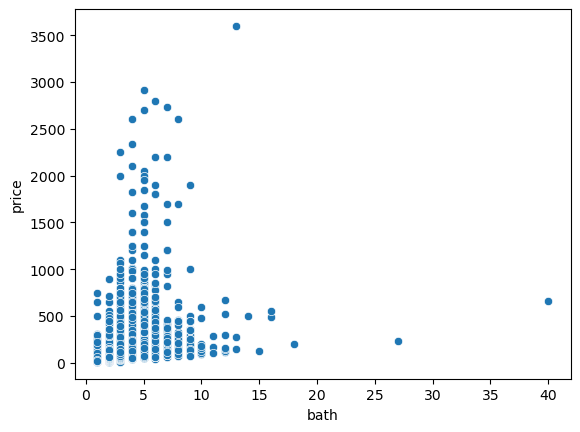

In [9]:
#3.1. Visualize the relationship between 'bath'and 'price' using scattered plot

sns.scatterplot(x = 'bath', y = 'price', data = df)

<Axes: xlabel='balcony', ylabel='price'>

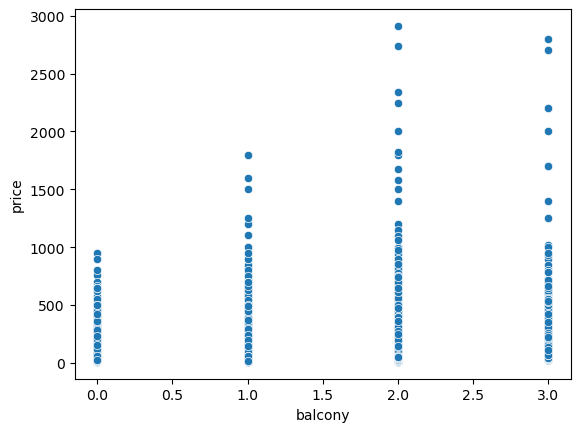

In [10]:
#3.2. Visualize the relationship between 'balcony'and 'price' using scattered plot
sns.scatterplot(x = 'balcony', y = 'price', data = df)

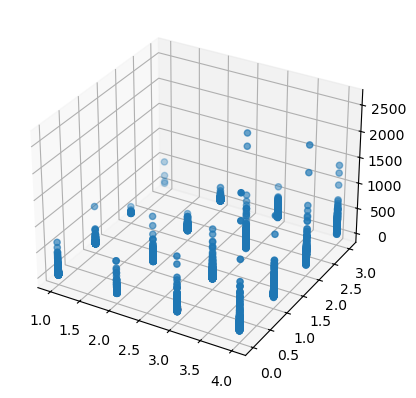

In [37]:
#3.3. Visualize the relationship between 'bath','balcony' and 'price' using 3D Scatterplot
# hint :fig = plt.figure(figsize=(8, 8))
# hint : ax = plt.axes(projection='3d')


# fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
ax.scatter3D(df['bath'], df['balcony'], df['price'])

<Axes: >

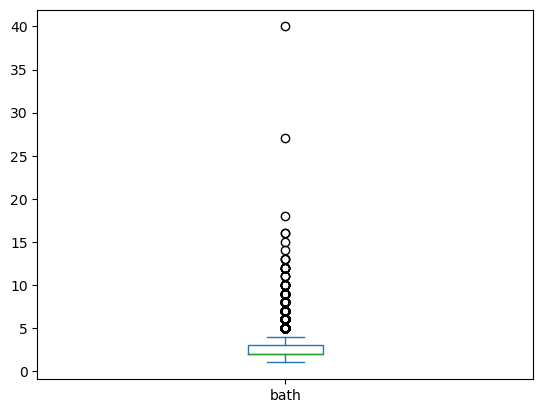

In [12]:
#3.4Show outliers distribution of variable 'bath' by drawing  Boxplot.
df.bath.plot(kind='box')

### 4. Pre-process the Dataframe as  Mentioned Below. (25 marks)

    1. Replace missing values of the feature 'balcony'  with numerical value 0 and convert its feature type to int.(2 marks)
    2. Replace missing values of the feature 'bath' missing values with numerical 1 and convert feature type to int.(2 marks)
    3. Replace missing values of the feature 'location'  with a constant "missing".(2 marks)
    4. Replace missing values of the feature 'society'  with a constant "missing".(2 marks)
    5. Convert the feature 'size' to int by removing albhabetic content and keep only numeric content. In case of  missing/null content replace by constant numeric value- 2. (3 marks)
    6. Convert the feature 'total_sqft' to numerical using 'to_numeric' method.Also, replace all its missing entries by mean.(3 marks)
    7. Eliminate all the outlies records/rows from Dtaframe with respect to feature'bath' (2 marks)
    8. convert 3 categorical features i.e. 'availability', 'location' and 'society' into numerical using label encoding. ( 6 marks)
    9.  Perfrom one hot encdoding on feature 'area_type' , also ensure output columns are of type int  (3 marks)

In [13]:
# 4.1 Replace missing values of the feature 'balcony' with numerical value 0 and convert its feature type to int.
# hint: use fillna( ).astype( )

# print(df.info())
df.balcony = df.balcony.fillna(0).astype(int)
# df.balcony


In [14]:
# 4.2 Replace missing values of the feature 'bath' missing values with numerical 1 and convert feature type to int
## hint: use fillna( ).astype( )

df.bath = df.bath.fillna(1).astype(int)

# df.info()

In [15]:
# 4.3 Replace missing values of the feature 'location'  with a constant "missing".
### hint: use fillna( )
# df.fillna()
df.location = df.location.fillna('missing')

# df[df.location=='missing']

# df.info()

In [16]:
# 4.4 Replace missing values of the feature 'society'  with a constant "missing".

df.society = df.society.fillna('missing')

In [17]:
# 4.5 Convert the feature 'size' to int by  and keep only numeric content.
#In case of  missing/null content replace by constant numeric value- 2.
# e.g. '2 BHK' to 2
# hint  : use str.replace(' BHK', '').str.replace(' Bedroom', '').str.replace(' RK', '')

df['size'] = df['size'].str.replace(' BHK', '').str.replace(' Bedroom', '').str.replace(' RK', '').fillna(2)
df['size'] = df['size'].astype(int)


# df['size'] = df['size'].apply(lambda x: int(x) if str(x).isdigit() else 2)


In [18]:
df['size'].value_counts()
# df.info()

size
2     5544
3     4857
4     1417
1      656
5      356
6      221
7      100
8       89
9       54
10      14
11       4
27       1
19       1
16       1
43       1
14       1
12       1
13       1
18       1
Name: count, dtype: int64

In [19]:
#4.6  Convert the feature 'total_sqft' to numerical using 'to_numeric' method .
#Also, replace all its missing entries by mean
# hint : use method pd.to_numeric( df["total_sqft"],errors="coerce")
# and fillna( df["total_sqft"].mean())


# df.info()

df.total_sqft = pd.to_numeric(df.total_sqft, errors='coerce')
df.total_sqft = df.total_sqft.fillna(df.total_sqft.mean())

In [20]:
df.bath.isna().sum()

0

In [21]:
# 4.7 Eliminate all the outlies records/rows from Dataframe with respect to feature'bath'

# # calculate the first quartile
# Q1 = df[' '].quantile(0.25)# calculate the first quartile
# # calculate the third quartile
# Q3 =df[' '].quantile(0.75)
# # The Interquartile Range (IQR) is defined as the difference between the third and first quartile
# # calculate IQR for each numeric variable
# IQR = Q3 - Q1
# # Define the upper and lower bounds for outliers
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# Eliminate all the outlies records/rows from Dataframe
#df = df[(df[' ']>lower_bound ) & (df[' '] < upper_bound)]






# 4.7 Eliminate all the outlies records/rows from Dataframe with respect to feature'bath'
q1 = df.bath.quantile(0.25)
q3 = df.bath.quantile(0.75)
iqr = q3 - q1
lb = q1 - 1.5*iqr
ub = q3 + 1.5*iqr
df = df[(df.bath < ub) & (df.bath > lb)]

In [22]:
#4.8. convert 3 categorical featurs i.e. 'availability', 'location' and 'society' into numerical using label encoding.
#  hint: LabelEncoder().fit_transform()

df.availability = LabelEncoder().fit_transform(df.availability)
df.location = LabelEncoder().fit_transform(df.location)
df.society = LabelEncoder().fit_transform(df.society)

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,40,383,2,452,1056.0,2,1,39.07
2,Built-up Area,80,1107,3,2631,1440.0,2,3,62.00
3,Super built-up Area,80,707,3,2141,1521.0,3,1,95.00
4,Super built-up Area,80,670,2,2631,1200.0,2,1,51.00
5,Super built-up Area,80,1175,2,591,1170.0,2,1,38.00


In [23]:
# 4.9  Perfrom one hot encdoding on feature 'area_type' , also ensure output columns are of type int
# hint pd.get_dummies(df, columns=['area_type'], prefix='', prefix_sep='',dtype= int)

df = pd.get_dummies(df, columns=['area_type'], dtype=int)

Part C (40 Marks)

### 5.  Perfrom Below Modeling Tasks (15 marks)
    1. Split the processed dataframe into 2 parts train and test with ratio as 70:30. Ensure feture 'price' as target(y). (3 marks)
    2. Use OLS statsmodels package to build the Linear Regression model on the train set.Also,generate the summary report.  (6 marks)
    3. Using sklearn's linear regression model train model on the train set and Interpret the coefficients. (6 marks)


In [24]:
# 5.1. Split the processed dataframe into 2 parts train and test with ratio as 70:30.
#Ensure feture 'price' as target(y).
# y = df['price']
# X = df.drop('price', axis=1)

# from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(df.drop('price', axis=1), df.price, test_size=0.3)


In [25]:
# 5.2. Use OLS statsmodels package to build the Linear Regression model on the train set.
#Also,generate the summary report.

# import statsmodels.api as sm
myModel = sm.OLS(ytrain, sm.add_constant(xtrain)).fit()
myModel.summary()


#generate the summary report.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     733.9
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:33:20   Log-Likelihood:                -49931.
No. Observations:                8596   AIC:                         9.988e+04
Df Residuals:                    8585   BIC:                         9.996e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                            -45.6895      4.791     -9.537      0.000     -55.081     -36.298
availability                       0.1140      0.048      2.398      0.017       0.021       0.207
location                          -0.0103      0.003     -4.067      0.000      -0.015      -0.005
size                              13.6906      1.758      7.788      0.000      10.245      17.137
society                            0.0004      0.001      0.383      0.701      -0.002       0.002
total_sqft                         0.0531      0.001     56.988      0.000       0.051       0.055
bath                              22.8188      1.913     11.927      0.000      19.069      26.569
balcony                           -6.4072      1.116     -5.741      0.000      -8.595      -4.219
area_type_Built-up  Area         -20.8199      2.931     -7.104      0.000     -26.565     -15.075
area_type_Carpet  Area           -25.0737      8.464     -2.962      0.003     -41.666      -8.482
area_type_Plot  Area              23.1626      3.503      6.612      0.000      16.295      30.030
area_type_Super built-up  Area   -22.9585      2.520     -9.110      0.000     -27.898     -18.019
==============================================================================
Omnibus:                     8886.065   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          8265547.176
Skew:                           4.191   Prob(JB):                         0.00
Kurtosis:                     154.681   Cond. No.                     3.74e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.12e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [26]:
# 5.3 Using sklearn's linear regression model train model on the train set and
#Interpret the coefficients.
#lr= LinearRegression()


lr = LinearRegression()
lr.fit(xtrain, ytrain)
(lr.coef_, lr.feature_names_in_)

[(i,j) for i,j in zip(lr.coef_, lr.feature_names_in_)]


[(0.11404480663787485, 'availability'),
 (-0.01028005895478784, 'location'),
 (13.690571373459408, 'size'),
 (0.0004076082465862366, 'society'),
 (0.053144101574064864, 'total_sqft'),
 (22.818776299838024, 'bath'),
 (-6.407204834697315, 'balcony'),
 (-9.397550013318064, 'area_type_Built-up  Area'),
 (-13.65134194710369, 'area_type_Carpet  Area'),
 (34.58500162418074, 'area_type_Plot  Area'),
 (-11.536109663758971, 'area_type_Super built-up  Area')]

### 6. Model Comparisons and Hyperparameter tuning  (25 Marks)

1. Train below models and obtain  values using 5 fold cross validation on train data and 'rmse' metric. Find the metric scorein test set and suggest the best model. ( 15 marks)
        - Ridge(alpha = 1, max_iter = 500)  (5 marks)
        - Lasso(alpha = 0.01, max_iter = 500) (5 marks)
        - ElasticNet(alpha = 0.1, l1_ratio = 0.01, max_iter = 500) (5 marks)

2.  Using Random serach on Lasso model find the best value of alpha and correxponding rmse value on test set. ( 10 marks)


#### 6.1  Train below models and obtain  values using 5 fold cross validation on train data and 'rmse' metric. Find the metric scorein test set and suggest the best model.
        - Ridge(alpha = 1, max_iter = 500)
        - Lasso(alpha = 0.01, max_iter = 500)
        - ElasticNet(alpha = 0.1, l1_ratio = 0.01, max_iter = 500)

In [27]:
# Train & evaluate Ridge
ridge = Ridge(alpha = 1, max_iter = 500)

# fit the model on train set

#  fetch cross validation score
# hint use cross_val_score() and scoring as 'neg_root_mean_squared_error'




# fetch rmse on test set
#hint :mean_squared_error(y_test, y_pred)

In [28]:
# Train & evaluate Lasso
lasso = Lasso(alpha = 0.01, max_iter = 500)

# fit the model on train set


#  fetch cross validation score
# hint use cross_val_score() and scoring as 'neg_root_mean_squared_error'



# fetch rmse on test set
#hint :mean_squared_error(y_test, y_pred)

In [29]:
## Train & evaluate ElasticNet
enet = ElasticNet(alpha = 0.1, l1_ratio = 0.01, max_iter = 500)

# fit the model on train set


#  fetch cross validation score
# hint use cross_val_score() and scoring as 'neg_root_mean_squared_error'



# fetch rmse on test set
#hint :mean_squared_error(y_test, y_pred)

In [35]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

# Define a function to automate the process for each model
def evaluate_model(model, name):
    # 1. Fit the model on the full training set
    model.fit(xtrain, ytrain)
    
    # 2. Fetch cross-validation scores (5-fold)
    # Note: cv_scores will be negative because sklearn uses 'scorers' where higher is better
    cv_scores = cross_val_score(model, xtrain, ytrain, cv=5, scoring='neg_root_mean_squared_error')
    avg_rmse_cv = -cv_scores.mean()
    
    # 3. Fetch RMSE on the test set
    ypred = model.predict(xtest)
    test_rmse = mean_squared_error(ytest, ypred)
    
    print(f"--- {name} Results ---")
    print(f"Average CV RMSE: {avg_rmse_cv:.4f}")
    print(f"Test RMSE:       {test_rmse:.4f}\n")
    
    return avg_rmse_cv, test_rmse

# 6.1 Train the models as per specified parameters
ridge_results = evaluate_model(Ridge(alpha=1, max_iter=500), "Ridge")

lasso_results = evaluate_model(Lasso(alpha=0.01, max_iter=500), "Lasso")

enet_results = evaluate_model(ElasticNet(alpha=0.1, l1_ratio=0.01, max_iter=500), "ElasticNet")

--- Ridge Results ---
Average CV RMSE: 82.0952
Test RMSE:       7178.2652

--- Lasso Results ---
Average CV RMSE: 82.0950
Test RMSE:       7178.3357

--- ElasticNet Results ---
Average CV RMSE: 82.3067
Test RMSE:       7240.0875



#### 6.2 Using Random serach CV on Lasso model find the best value of alpha and corresponding rmse value on test set.



In [31]:

# Random serach on Lasso
# import function to perform RandomizedSearchCV

# hint use : tuned_paramaters = [{'alpha':[0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40, 60], }]

# initiate the elastic net regression model
lasso = Lasso()



# hint use RandomizedSearchCV ()


# fit the Randomise serch CV model on X_train and y_train using fit()


# get the best parameters


# and print  corresponding rmse value on test set.


In [32]:
dir(sm)

['BayesGaussMI',
 'BinomialBayesMixedGLM',
 'ConditionalLogit',
 'ConditionalMNLogit',
 'ConditionalPoisson',
 'Factor',
 'GEE',
 'GLM',
 'GLMGam',
 'GLS',
 'GLSAR',
 'GeneralizedPoisson',
 'HurdleCountModel',
 'Logit',
 'MANOVA',
 'MI',
 'MICE',
 'MICEData',
 'MNLogit',
 'MixedLM',
 'NegativeBinomial',
 'NegativeBinomialP',
 'NominalGEE',
 'OLS',
 'OrdinalGEE',
 'PCA',
 'PHReg',
 'Poisson',
 'PoissonBayesMixedGLM',
 'ProbPlot',
 'Probit',
 'QuantReg',
 'RLM',
 'RecursiveLS',
 'SurvfuncRight',
 'TruncatedLFNegativeBinomialP',
 'TruncatedLFPoisson',
 'WLS',
 'ZeroInflatedGeneralizedPoisson',
 'ZeroInflatedNegativeBinomialP',
 'ZeroInflatedPoisson',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__version__',
 '__version_info__',
 'add_constant',
 'categorical',
 'cov_struct',
 'datasets',
 'distributions',
 'duration',
 'emplike',
 'families',
 'formula',
 'gam',
 'genmod',
 'graphics',
 'iolib',
 'load',
 

In [33]:
help(df.balcony.astype)

Help on method astype in module pandas.core.generic:

astype(dtype, copy: 'bool_t | None' = None, errors: 'IgnoreRaise' = 'raise') -> 'Self' method of pandas.core.series.Series instance
    Cast a pandas object to a specified dtype ``dtype``.

    Parameters
    ----------
    dtype : str, data type, Series or Mapping of column name -> data type
        Use a str, numpy.dtype, pandas.ExtensionDtype or Python type to
        cast entire pandas object to the same type. Alternatively, use a
        mapping, e.g. {col: dtype, ...}, where col is a column label and dtype is
        a numpy.dtype or Python type to cast one or more of the DataFrame's
        columns to column-specific types.
    copy : bool, default True
        Return a copy when ``copy=True`` (be very careful setting
        ``copy=False`` as changes to values then may propagate to other
        pandas objects).

        .. note::
            The `copy` keyword will change behavior in pandas 3.0.
            `Copy-on-Write
 

In [34]:
help(pd.get_dummies)

Help on function get_dummies in module pandas.core.reshape.encoding:

get_dummies(data, prefix=None, prefix_sep: 'str | Iterable[str] | dict[str, str]' = '_', dummy_na: 'bool' = False, columns=None, sparse: 'bool' = False, drop_first: 'bool' = False, dtype: 'NpDtype | None' = None) -> 'DataFrame'
    Convert categorical variable into dummy/indicator variables.

    Each variable is converted in as many 0/1 variables as there are different
    values. Columns in the output are each named after a value; if the input is
    a DataFrame, the name of the original variable is prepended to the value.

    Parameters
    ----------
    data : array-like, Series, or DataFrame
        Data of which to get dummy indicators.
    prefix : str, list of str, or dict of str, default None
        String to append DataFrame column names.
        Pass a list with length equal to the number of columns
        when calling get_dummies on a DataFrame. Alternatively, `prefix`
        can be a dictionary mapp